# 04 — Frozen Lake + Exploration
**Week 3 | RL Fundamentals**

First contact with **Gymnasium**. We run various policies on Frozen Lake and measure performance — no learning yet, just understanding the environment and the exploration-exploitation trade-off.

In [1]:
# Install gymnasium if needed
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
print('Gymnasium version:', gym.__version__)


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Gymnasium version: 1.3.0


In [2]:
env = gym.make('FrozenLake-v1', is_slippery=False)
print(f"Observation space: {env.observation_space}  ({env.observation_space.n} states)")
print(f"Action space:      {env.action_space}  (0=L, 1=D, 2=R, 3=U)")
print(f"\nTransition model for state 0, action 1 (DOWN):")
for prob, next_s, reward, done in env.unwrapped.P[0][1]:
    print(f"  P={prob:.2f} -> state {next_s}, reward={reward}, done={done}")

Observation space: Discrete(16)  (16 states)
Action space:      Discrete(4)  (0=L, 1=D, 2=R, 3=U)

Transition model for state 0, action 1 (DOWN):
  P=1.00 -> state 4, reward=0, done=False


## 1. Random Policy Baseline

In [3]:
def evaluate_policy(env, policy_fn, n_episodes=1000, max_steps=200):
    wins = 0
    returns = []
    for _ in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0
        for _ in range(max_steps):
            a = policy_fn(s)
            s, r, terminated, truncated, _ = env.step(a)
            ep_return += r
            if terminated or truncated:
                if r == 1.0: wins += 1
                break
        returns.append(ep_return)
    return wins / n_episodes, np.mean(returns)

random_win, random_ret = evaluate_policy(env, lambda s: env.action_space.sample())
print(f"Random policy:  win rate={random_win:.2%}, avg return={random_ret:.4f}")

Random policy:  win rate=1.70%, avg return=0.0170


## 2. Fixed Directional Policy
Manually specify the best deterministic path.

In [4]:
# Hand-crafted policy for 4x4 non-slippery FrozenLake (actions: 0=L,1=D,2=R,3=U)
# Map: SFFF / FHFH / FFFH / HFFG
hand_policy = [
    1, 2, 1, 0,   # row 0
    1, 0, 1, 0,   # row 1 (H at pos 5,7)
    2, 2, 1, 0,   # row 2
    0, 2, 2, 0,   # row 3 (H at pos 12, G at 15)
]
hand_win, hand_ret = evaluate_policy(env, lambda s: hand_policy[s])
print(f"Hand policy:    win rate={hand_win:.2%}, avg return={hand_ret:.4f}")

Hand policy:    win rate=100.00%, avg return=1.0000


## 3. ε-greedy Policy with Learned Bias
Start with a 'smart' action bias and add exploration noise.

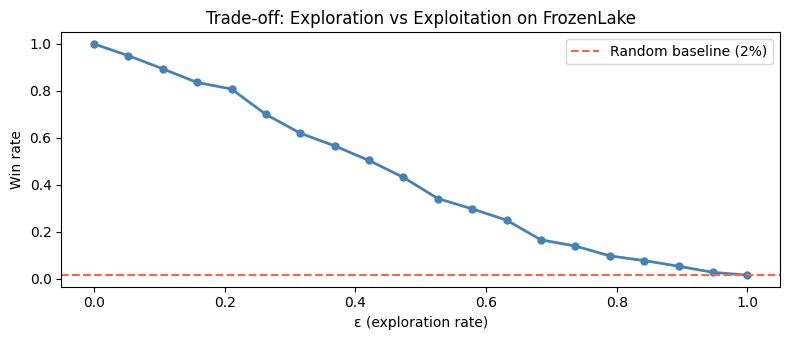

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
eps_values = np.linspace(0, 1, 20)
results = []
for eps in eps_values:
    def eps_hand(s, eps=eps):
        if np.random.rand() < eps:
            return env.action_space.sample()
        return hand_policy[s]
    w, _ = evaluate_policy(env, eps_hand, n_episodes=500)
    results.append(w)
ax.plot(eps_values, results, color='steelblue', linewidth=2, marker='o', markersize=5)
ax.axhline(random_win, color='tomato', linestyle='--', label=f'Random baseline ({random_win:.0%})')
ax.set_xlabel('ε (exploration rate)'); ax.set_ylabel('Win rate')
ax.set_title('Trade-off: Exploration vs Exploitation on FrozenLake')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Inspect the MDP Transitions

In [6]:
# Show how slippery=True changes things
env_slip = gym.make('FrozenLake-v1', is_slippery=True)
slip_win, _ = evaluate_policy(env_slip, lambda s: hand_policy[s])
print(f"Hand policy on SLIPPERY lake: win rate={slip_win:.2%}")
print("\n(Our deterministic policy fails on a stochastic environment!)")

Hand policy on SLIPPERY lake: win rate=3.80%

(Our deterministic policy fails on a stochastic environment!)


## ✅ Exercises
1. Try the 8×8 FrozenLake map (`map_name='8x8'`). Does the hand-crafted policy still work? Why not?
2. Plot win rate vs number of evaluation episodes for the random policy. How many episodes do you need for a stable estimate?
3. **Challenge**: write a systematic policy for the slippery lake — one that avoids dangerous edges. Test it.

## Question 1.

In [7]:
env_8x8 = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=False)
print(f"Observation space: {env_8x8.observation_space}  ({env_8x8.observation_space.n} states)")
print(f"Action space:      {env_8x8.action_space}")

Observation space: Discrete(64)  (64 states)
Action space:      Discrete(4)


In [8]:
hand_win_8x8, hand_ret_8x8 = evaluate_policy(env_8x8, lambda s: hand_policy[s])
print(f"Hand policy on 8x8: win rate={hand_win_8x8:.2%}, avg return={hand_ret_8x8:.4f}")

IndexError: list index out of range

No, The 8x8 Frozen lake didn't worked it crases because of an IndexError: list index out of range .
The 8x8 map has 64 states (confirmed by Observation space: Discrete(64) in my output), but hand_policy is just a 16 item list, built specifically for the 4x4 grid which only has 16 states. So as soon as the random walk reaches any state with index 16 or above, hand_policy tries to look something up that just doesn't exist in the list, and python throws the error.

## Question 2.

In [16]:
episode_counts = [10, 50, 100, 500, 1000, 2000, 5000]
win_rates = []

for n in episode_counts:
    w, _ = evaluate_policy(env, lambda s: env.action_space.sample(), n_episodes=n)
    win_rates.append(w)
    print(f"n_episodes={n:>5}: win rate={w:.4f}")

n_episodes=   10: win rate=0.0000
n_episodes=   50: win rate=0.0000
n_episodes=  100: win rate=0.0200
n_episodes=  500: win rate=0.0180
n_episodes= 1000: win rate=0.0150
n_episodes= 2000: win rate=0.0140
n_episodes= 5000: win rate=0.0126


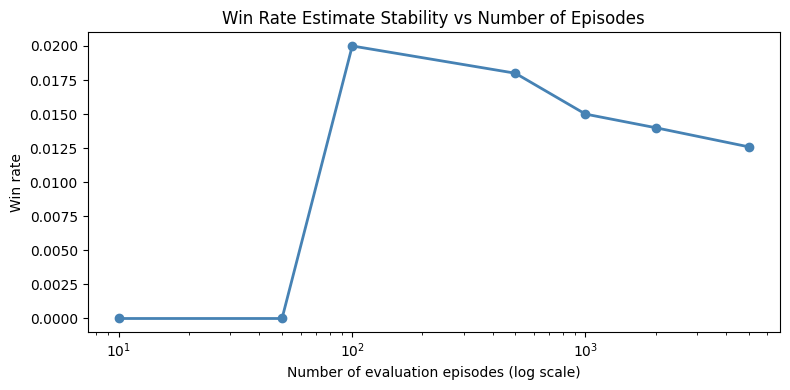

In [17]:
plt.figure(figsize=(8,4))
plt.plot(episode_counts, win_rates, marker='o', color='steelblue', linewidth=2)
plt.xscale('log')
plt.xlabel('Number of evaluation episodes (log scale)')
plt.ylabel('Win rate')
plt.title('Win Rate Estimate Stability vs Number of Episodes')
plt.tight_layout(); plt.show()

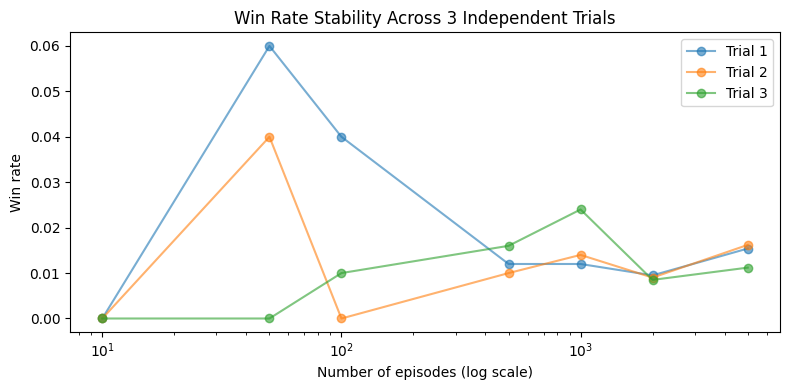

In [18]:
plt.figure(figsize=(8,4))
for trial in range(3):
    win_rates_trial = []
    for n in episode_counts:
        w, _ = evaluate_policy(env, lambda s: env.action_space.sample(), n_episodes=n)
        win_rates_trial.append(w)
    plt.plot(episode_counts, win_rates_trial, marker='o', alpha=0.6, label=f'Trial {trial+1}')

plt.xscale('log')
plt.xlabel('Number of episodes (log scale)')
plt.ylabel('Win rate')
plt.title('Win Rate Stability Across 3 Independent Trials')
plt.legend()
plt.tight_layout(); plt.show()

Re-running this a couple times, the exact shape of the noise changes each time (since there's no fixed random seed), but the same pattern keeps showing up. At small n (10, 50, 100), the three trials disagree a lot estimates can range from 0% all the way up to 5-6%, just from random luck. Once n gets to around 500 or more, the three trial lines come together and settle into a tight band around 0.01-0.02 (roughly 1-2%), and they stay close together all the way to n=5000.

So the random policy's real win rate is probably around 1-2%, and you need at least a few hundred episodes (500+) before the estimate becomes trustworthy. Below that, the result is mostly just noise and depends a lot on which specific episodes happened to succeed.

## Question 3.

In [19]:
env_slip = gym.make('FrozenLake-v1', is_slippery=True)
n_states = env_slip.observation_space.n
n_actions = env_slip.action_space.n
P = env_slip.unwrapped.P  # P[state][action] = list of (prob, next_state, reward, done)

print(f"States: {n_states}, Actions: {n_actions}")
print("\nExample - transitions for state 0, action 1 (DOWN):")
for prob, next_s, reward, done in P[0][1]:
    print(f"  P={prob:.2f} -> state {next_s}, reward={reward}, done={done}")

States: 16, Actions: 4

Example - transitions for state 0, action 1 (DOWN):
  P=0.33 -> state 0, reward=0, done=False
  P=0.33 -> state 4, reward=0, done=False
  P=0.33 -> state 1, reward=0, done=False


In [20]:
def value_iteration(P, n_states, n_actions, gamma=0.99, theta=1e-8):
    V = np.zeros(n_states)
    while True:
        delta = 0
        for s in range(n_states):
            action_values = []
            for a in range(n_actions):
                value = sum(prob * (reward + gamma * V[next_s] * (not done))
                            for prob, next_s, reward, done in P[s][a])
                action_values.append(value)
            best_value = max(action_values)
            delta = max(delta, abs(best_value - V[s]))
            V[s] = best_value
        if delta < theta:
            break

    # extract policy from final V
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        action_values = []
        for a in range(n_actions):
            value = sum(prob * (reward + gamma * V[next_s] * (not done))
                        for prob, next_s, reward, done in P[s][a])
            action_values.append(value)
        policy[s] = np.argmax(action_values)
    return policy, V

systematic_policy, V_optimal = value_iteration(P, n_states, n_actions)
print("Systematic (optimal) policy:", systematic_policy)

Systematic (optimal) policy: [0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]


In [21]:
sys_win, sys_ret = evaluate_policy(env_slip, lambda s: systematic_policy[s])
print(f"Systematic policy on slippery lake: win rate={sys_win:.2%}, avg return={sys_ret:.4f}")
print(f"Original hand policy on slippery lake: win rate={slip_win:.2%}")

Systematic policy on slippery lake: win rate=74.10%, avg return=0.7410
Original hand policy on slippery lake: win rate=3.80%
